In [1]:
# ================================================
# Notebook 2: Image Preprocessing
# Purpose: Clean and enhance messy handwriting images
# (Doctor prescriptions & student notes)
# ================================================

print("📸 Notebook 2: Image Preprocessing Started")

📸 Notebook 2: Image Preprocessing Started


In [2]:
# Import required Libraries
# Cell 2: Imports
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
from pathlib import Path

print("✅ Libraries imported for preprocessing")

✅ Libraries imported for preprocessing


In [3]:
#Preprocessing Function
# Cell 3: Main Preprocessing Function
def preprocess_handwriting(image_path, show_steps=True):
    """
    Preprocess messy handwriting images for better OCR accuracy.
    """
    # Read the image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"❌ Could not read image: {image_path}")
    
    original = img.copy()
    
    # Step 1: Convert to Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Step 2: Noise Reduction (Gaussian Blur)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # Step 3: Adaptive Thresholding (Best for uneven lighting)
    thresh = cv2.adaptiveThreshold(blurred, 255, 
                                   cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                   cv2.THRESH_BINARY_INV, 11, 2)
    
    # Step 4: Dilation - Connect broken letters
    kernel = np.ones((2, 2), np.uint8)
    dilated = cv2.dilate(thresh, kernel, iterations=1)
    
    # Step 5: Optional - Light erosion to remove noise
    final = cv2.erode(dilated, kernel, iterations=1)
    
    # Convert to PIL format for TrOCR
    final_pil = Image.fromarray(cv2.cvtColor(final, cv2.COLOR_GRAY2RGB))
    
    print(f"✅ Preprocessing completed for: {os.path.basename(image_path)}")
    
    # Show all steps if enabled
    if show_steps:
        fig, axs = plt.subplots(2, 3, figsize=(15, 8))
        axs[0,0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
        axs[0,0].set_title("1. Original")
        axs[0,0].axis('off')
        
        axs[0,1].imshow(gray, cmap='gray')
        axs[0,1].set_title("2. Grayscale")
        axs[0,1].axis('off')
        
        axs[0,2].imshow(blurred, cmap='gray')
        axs[0,2].set_title("3. Blurred")
        axs[0,2].axis('off')
        
        axs[1,0].imshow(thresh, cmap='gray')
        axs[1,0].set_title("4. Thresholded")
        axs[1,0].axis('off')
        
        axs[1,1].imshow(dilated, cmap='gray')
        axs[1,1].set_title("5. Dilated")
        axs[1,1].axis('off')
        
        axs[1,2].imshow(final, cmap='gray')
        axs[1,2].set_title("6. Final Processed")
        axs[1,2].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    return final_pil, final


In [4]:
# Batch Preprocessing Function
# Cell 4: Process All Images in a Folder
def preprocess_folder(input_folder="input_images", output_folder="processed_images"):
    os.makedirs(output_folder, exist_ok=True)
    
    image_files = [f for f in os.listdir(input_folder) 
                   if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff'))]
    
    print(f"Found {len(image_files)} images to preprocess...\n")
    
    for filename in image_files:
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, f"processed_{filename}")
        
        try:
            processed_pil, processed_cv = preprocess_handwriting(input_path, show_steps=False)
            processed_pil.save(output_path)
            print(f"✅ Saved: processed_{filename}")
        except Exception as e:
            print(f"❌ Failed {filename}: {e}")
    
    print(f"\n🎉 All images processed and saved in '{output_folder}' folder")

✅ Preprocessing completed for: 1_3xUyINxRtDf2qowd-kkGQA.jpg


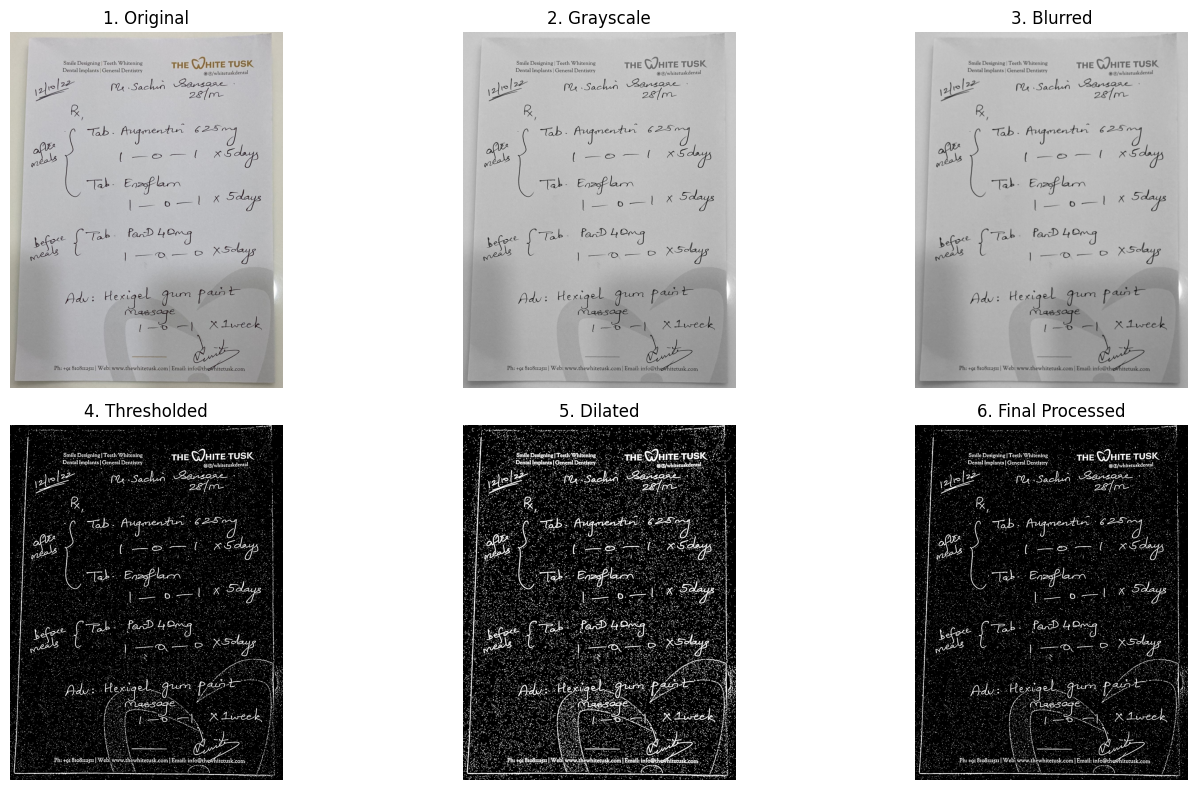

✅ Processed image saved as 'processed_test_image.jpg'


In [6]:
# Test Preprocessing on One Image
# Cell 5: Test on Single Image
# ============================
# Change this path to your image
test_image = r"C:\Users\Avilasha\Desktop\handwriting-ocr\input_images\1_3xUyINxRtDf2qowd-kkGQA.jpg"

# Run preprocessing with visualization
processed_pil, processed_cv = preprocess_handwriting(test_image, show_steps=True)

# Save the processed image
processed_pil.save("processed_test_image.jpg")
print("✅ Processed image saved as 'processed_test_image.jpg'")

In [7]:
# Cell 6: Preprocess All Images in Folder (Recommended)
preprocess_folder(input_folder="input_images", 
                  output_folder="processed_images")

Found 1 images to preprocess...

✅ Preprocessing completed for: 1_3xUyINxRtDf2qowd-kkGQA.jpg
✅ Saved: processed_1_3xUyINxRtDf2qowd-kkGQA.jpg

🎉 All images processed and saved in 'processed_images' folder
